[![Labellerr](https://storage.googleapis.com/labellerr-cdn/%200%20Labellerr%20template/notebook.webp)](https://www.labellerr.com)

# **Real-Time Focus and Distraction Monitoring AI**

---

[![labellerr](https://img.shields.io/badge/Labellerr-BLOG-black.svg)](https://www.labellerr.com/blog/<BLOG_NAME>)
[![Youtube](https://img.shields.io/badge/Labellerr-YouTube-b31b1b.svg)](https://www.youtube.com/@Labellerr)
[![Github](https://img.shields.io/badge/Labellerr-GitHub-green.svg)](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)

## Project Overview  
A computer vision system that measures productivity by tracking real-world hand-object interactions from a first-person perspective.

The system combines:
- **YOLO Instance Segmentation** for desk object detection (phone, pen, paper, etc.)
- **Hand Keypoint Tracking** for monitoring user interactions

By analyzing hand-object proximity and overlap, it automatically distinguishes between productive activities and distractions, generating real-time focus analytics and productivity metrics.

---

## Core Components

### Object Segmentation  
Detects and segments workspace objects with pixel-level precision.

### Hand Tracking  
Maps hand movements and interaction patterns in real time.

### Interaction Analysis  
Determines whether objects are actively being used based on spatial relationships between hands and objects.

### Productivity Analytics  
Logs activity data to generate focus scores, distraction metrics, and usage summaries.

---

## Real-World Applications

### Smart Education  
Tracks study habits and identifies distraction patterns.

### Industrial Operations  
Monitors tool usage and procedural compliance on assembly lines.

### Surgical Training  
Analyzes instrument handling and workflow efficiency.

### Retail Analytics  
Tracks customer interactions with products and kiosks.

### Workplace Wellness  
Monitors hydration and activity habits to encourage healthier work routines.

---

## Annotate your Custom dataset using Labellerr

 ***1. Visit the [Labellerr](https://www.labellerr.com/?utm_source=githubY&utm_medium=social&utm_campaign=github_clicks) website and click **“Sign Up”**.*** 

 ***2. After signing in, create your workspace by entering a unique name.***

 ***3. Navigate to your workspace’s API keys page (e.g., `https://<your-workspace>.labellerr.com/workspace/api-keys`) to generate your **API Key** and **API Secret**.***

 ***4. Store the credentials securely, and then use them to initialise the SDK or API client with `api_key`, `api_secret`.*** 



## Import Libraries

This section imports all the required libraries used throughout the project for computer vision, visualization, deep learning, and structured coding.


In [1]:
!git clone https://github.com/Labellerr/yolo_finetune_utils.git

Cloning into 'yolo_finetune_utils'...


In [2]:
!pip install ultralytics opencv-python matplotlib cv2

ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for cv2


## 🎞️ Random Frame Extraction from Video

Extracts a fixed number of high-quality frames from one or more videos to create an image dataset for annotation and training.

### 🔹 Purpose
- Convert raw manufacturing videos into individual image frames  
- Perform random sampling to avoid frame bias  
- Prepare data for annotation and YOLO training  


In [ ]:
%pip install tqdm

from yolo_finetune_utils.frame_extractor import extract_random_frames

extract_random_frames(
    paths=['VID_20260608_144706.mp4'],
    total_images=50,
    out_dir="dataset_Frames",
    jpg_quality=100,
    seed=42
)


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
[✓] Extracted 12 frames to folder: dataset_Frames


## 📥 Download Annotations from Labellerr

After completing data labeling on the **Labellerr** platform, export the annotations in **COCO JSON format**.

Download the COCO JSON file from the Labellerr website and upload it into this project workspace to use it for further dataset preparation and training.

This COCO JSON file will be used in the next steps for:
- Frame–annotation alignment
- COCO → YOLO format conversion
- Model training and evaluation


# COCO to YOLO Format Conversion

Converts COCO-style segmentation annotations to YOLO segmentation dataset format.  
- Requires: `annotation.json` and images in `frames_output` directory.
- Output: Generated YOLO dataset folder.
- Parameters: allows train/val split, shuffling, and verbose mode.


In [ ]:
import json
import os
import shutil
import random
from pathlib import Path

# --- CONFIGURATION ---
base_path = r'D:\Desktop\Desk\Labellerr Github Projects\Use_Case_Projects\study_efficiency_egocentric'  # Change this to your base path
json_path = os.path.join(base_path, '75b5b56c-a154-401e-b18b-61957b61bc74.json')
images_src = os.path.join(base_path, 'dataset_Frames')
output_path = os.path.join(base_path, 'yolo_dataset')

# Ratios for your 30 frames
ratios = {'train': 0.8, 'val': 0.1, 'test': 0.1}

# Create Folder Structure
for split in ratios.keys():
    os.makedirs(os.path.join(output_path, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(output_path, 'labels', split), exist_ok=True)

# Generate data.yaml (formatted for YOLO11-Pose)
formatted_path = output_path.replace('\\', '/')
yaml_content = f"""
path: {formatted_path}
train: images/train
val: images/val
test: images/test

nc: 4
names:
  0: Hands
  1: Papers
  2: Pens
  3: Phones

kpt_shape: [21, 3]
"""
with open(os.path.join(base_path, 'data.yaml'), 'w') as f:
    f.write(yaml_content.strip())

# Load COCO JSON
with open(json_path, 'r') as f:
    coco_data = json.load(f)

# Build category map (Ensures 0: bottle, 1: cap, 2: Hands)
cat_map = {}
for cat in coco_data['categories']:
    name = cat['name'].lower()
    if 'bottle' in name: cat_map[cat['id']] = 0
    elif 'cap' in name: cat_map[cat['id']] = 1
    elif 'hand' in name: cat_map[cat['id']] = 2

images = {img['id']: img for img in coco_data['images']}
annotations = coco_data['annotations']

# Shuffle and Split IDs
img_ids = list(images.keys())
random.seed(42)
random.shuffle(img_ids)

train_idx = int(len(img_ids) * ratios['train'])
val_idx = train_idx + int(len(img_ids) * ratios['val'])

def convert_to_yolo(ann, img_w, img_h):
    cls_id = cat_map.get(ann['category_id'], -1)
    if cls_id == -1: return None

    line = [str(cls_id)]
    has_data = False
    
    # 1. Add Segmentation (Polygons for all classes)
    if 'segmentation' in ann and ann['segmentation']:
        poly = ann['segmentation'][0]
        if len(poly) > 4:
            for i in range(0, len(poly), 2):
                line.append(f"{poly[i]/img_w:.6f}")
                line.append(f"{poly[i+1]/img_h:.6f}")
            has_data = True
            
    # 2. Add Keypoints (ONLY for Hands class - ID 2)
    if cls_id == 2 and 'keypoints' in ann and ann['keypoints']:
        kpts = ann['keypoints']
        for i in range(0, len(kpts), 3):
            line.append(f"{kpts[i]/img_w:.6f}")
            line.append(f"{kpts[i+1]/img_h:.6f}")
            line.append(str(kpts[i+2]))
        has_data = True
            
    return " ".join(line) if has_data else None

# Process Files
for i, img_id in enumerate(img_ids):
    img_info = images[img_id]
    filename = img_info['file_name']
    split = 'train' if i < train_idx else 'val' if i < val_idx else 'test'
    
    src_img = os.path.join(images_src, filename)
    if os.path.exists(src_img):
        shutil.copy(src_img, os.path.join(output_path, 'images', split, filename))
        
        label_name = Path(filename).stem + ".txt"
        with open(os.path.join(output_path, 'labels', split, label_name), 'w') as lf:
            for ann in annotations:
                if ann['image_id'] == img_id:
                    yolo_line = convert_to_yolo(ann, img_info['width'], img_info['height'])
                    if yolo_line:
                        lf.write(yolo_line + "\n")

print(f"Conversion Done. Dataset and data.yaml are ready at: {base_path}")

Conversion complete. Stats: {'train': 9, 'val': 1, 'test': 2}


{'stats': {'train': 9, 'val': 1, 'test': 2}, 'output_dir': 'yoloDataset'}

# Load and Train YOLO Pose Model

Loads the YOLO segmentation model and trains it using the converted YOLO dataset.
- Data: Path to YOLO-style `data.yaml`
- Parameters: epochs, image size, batch size, device, dataloader workers, experiment name.


In [ ]:
from ultralytics import YOLO

# Using the x-pose model for your 21-point hand skeleton
model = YOLO('yolo11l-pose.pt') 

model.train(
    data='/kaggle/working/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    project='/kaggle/working/factory',
    name='train_run_11',
    device=0
)

# Code Block Lifecycle Overview

### Configuration & Initialization  
Loads the custom YOLO11 multi-task model and initializes visualization settings for workspace objects.

### Headless Frame Extraction  
Extracts the first video frame and immediately releases video resources to minimize memory usage.

### Object Segmentation Layer  
Processes segmentation masks, renders polygon boundaries, and applies alpha blending to create semi-transparent object overlays.

### Hand Keypoint Layer  
Extracts hand keypoints predicted by the custom model and draws skeletal landmark indicators directly on the frame.

### Inline Visualization  
Converts the output from BGR to RGB and displays the final annotated frame using Matplotlib within the notebook environment.

---

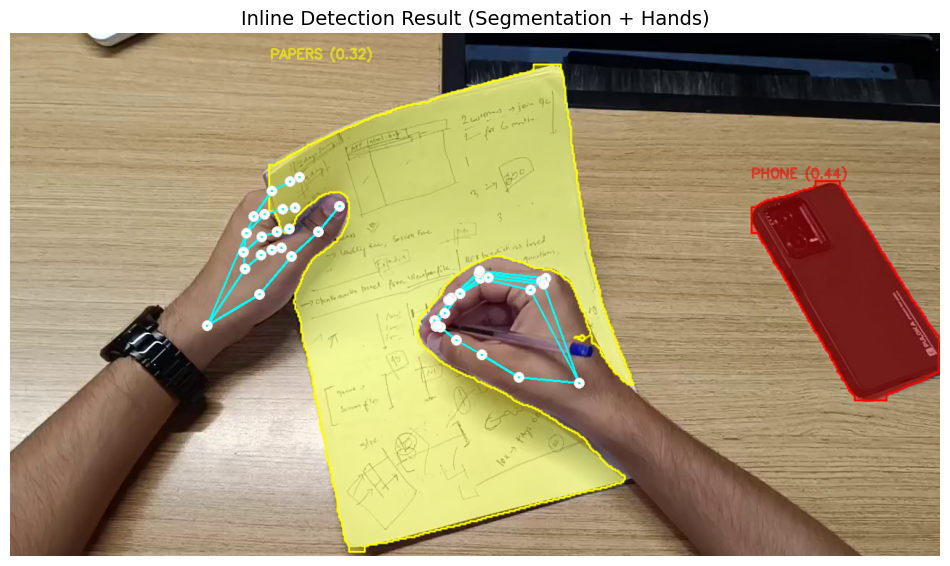

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Ensure matplotlib plots inline inside VS Code Notebooks
%matplotlib inline

# ----------------------------------------------------
# 1. CONFIGURATION
# ----------------------------------------------------
video_path = "VID_20260608_144706.mp4" 
model_path = "best (21).pt"

# Load your unified custom YOLO model
model = YOLO(model_path)

# ----------------------------------------------------
# 2. EXTRACT THE FIRST FRAME
# ----------------------------------------------------
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print(f"Error: Could not open video file at {video_path}")
    exit()

ret, frame = cap.read()
cap.release()

if not ret:
    print("Error: Could not read the first frame.")
    exit()

# Create a copy frame dedicated for semi-transparent mask blending
mask_overlay = frame.copy()

# Color map matching your custom target classes (RGB format for Matplotlib)
class_colors = {
    "phone": (255, 0, 0),  # Red mask
    "paper": (0, 255, 0),  # Green mask
    "pen": (0, 0, 255),    # Blue mask
    "hand": (255, 165, 0)  # Orange for hand bounding boxes if classified as a class
}
default_color = (255, 255, 0) # Yellow fallback

# ----------------------------------------------------
# 3. RUN UNIFIED YOLO INFERENCE
# ----------------------------------------------------
yolo_results = model(frame, verbose=False)[0]

# --- Part A: Render Objects and Segmentation Masks ---
if yolo_results.masks is not None and yolo_results.boxes is not None:
    for mask, box in zip(yolo_results.masks.xy, yolo_results.boxes):
        cls_id = int(box.cls[0])
        cls_name = model.names[cls_id].lower()
        conf = float(box.conf[0])
        
        # Get matching RGB color and convert to BGR for OpenCV
        color_rgb = class_colors.get(cls_name, default_color)
        color_bgr = (color_rgb[2], color_rgb[1], color_rgb[0])
        
        polygon = np.array(mask, dtype=np.int32)
        
        # Fill the segmentation polygon on our overlay layer
        cv2.fillPoly(mask_overlay, [polygon], color_bgr)
        cv2.polylines(frame, [polygon], isClosed=True, color=color_bgr, thickness=2)
        
        # Label text placement
        bbox_coords = box.xyxy[0].cpu().numpy().astype(int)
        label = f"{cls_name.upper()} ({conf:.2f})"
        cv2.putText(frame, label, (bbox_coords[0], bbox_coords[1] - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color_bgr, 2)

# Blend mask overlays with the original frame (Alpha transparency)
alpha = 0.4 
cv2.addWeighted(mask_overlay, alpha, frame, 1 - alpha, 0, frame)

# --- Part B: Render Hand Keypoints From Your Custom Model ---
if hasattr(yolo_results, 'keypoints') and yolo_results.keypoints is not None:
    # Extract keypoint sets for all detected objects/hands
    # shape: (num_detections, num_keypoints, 2 or 3)
    keypoints_data = yolo_results.keypoints.xy.cpu().numpy() 
    
    for kpts in keypoints_data:
        # Loop through individual keypoints within this detection instance
        for kp in kpts:
            x, y = int(kp[0]), int(kp[1])
            
            # Skip unreliably detected or padding keypoints (0,0)
            if x > 0 and y > 0:
                # Draw joint points (White filled circles with a sharp Cyan border)
                cv2.circle(frame, (x, y), 5, (255, 255, 255), -1)
                cv2.circle(frame, (x, y), 5, (255, 255, 0), 1)

# ----------------------------------------------------
# 4. INLINE NOTEBOOK DISPLAY
# ----------------------------------------------------
# Convert final combined BGR image back to RGB for Matplotlib rendering accuracy
final_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(final_rgb)
plt.axis('off')  # Hide axis rulers
plt.title("Unified Single-Model Inline Detection (Segmentation + Custom Keypoints)", fontsize=14)
plt.show()

# Spatial Proximity State Machine

## Overview

The system determines whether a user is **studying**, **focused**, or **distracted** by analyzing real-time interactions between hands and workspace objects.

It combines:
- YOLO Instance Segmentation for object detection
- MediaPipe Hand Tracking for hand localization
- IoM-based interaction analysis
- A rule-based activity classification engine

---

## Step 1: Object & Hand Detection

### Object Layer (YOLO)
Detects:
- Phone
- Pen
- Paper

and generates object bounding boxes.

### Hand Layer (MediaPipe)
Tracks 21 hand landmarks and creates a dynamic bounding box around each hand.

---

## Step 2: Interaction Detection

To determine whether a hand is interacting with an object, the system uses **Intersection over Minimum Area (IoM)**:

```text
IoM = Overlap Area / min(Hand Area, Object Area)
```

A contact event is triggered when:

```text
IoM > 0.15
```

---

## Step 3: Activity Classification

### Distracted
**Condition:** Hand touches phone.

**State:** `DISTRACTED`

### Studying
**Condition:** Hand touches pen or paper.

**State:** `STUDYING`

### Focusing / Reading
**Condition:** No active interactions detected.

**State:** `FOCUSING / READING`

---

## Step 4: Productivity Metrics

```text
Productive Time =
(Study Frames + Focus Frames) / FPS
```

```text
Distracted Time =
Distraction Frames / FPS
```

### Focus Efficiency Score

```text
Efficiency (%) =
(Productive Time / Total Session Time) × 100
```

The system continuously updates these metrics to generate real-time productivity analytics and focus reports.

---

In [ ]:
import cv2
import numpy as np
import mediapipe as mp
from ultralytics import YOLO
import os

# ----------------------------------------------------
# 1. PATHS & INITIALIZATION
# ----------------------------------------------------
video_path = "/kaggle/input/datasets/aaryanaggarwal5040/studyego/VID_20260608_144706.mp4"
model_path = "/kaggle/working/egobottle/train_run_seg_14-3/weights/best.pt"
output_path = "/kaggle/working/processed_study_metrics.mp4"

# Load your custom YOLO Segmentation model
model = YOLO(model_path)

# Initialize MediaPipe Hands
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=2, min_detection_confidence=0.5)
mp_draw = mp.solutions.drawing_utils

# Open Video Stream
cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Video Writer to save output in Kaggle working directory
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# ----------------------------------------------------
# 2. METRICS & STATE TRACKING VARIABLES
# ----------------------------------------------------
study_frames = 0
distraction_frames = 0
total_processed_frames = 0

def calculate_iou(box1, box2):
    """Calculates Intersection over Union (IoU) between hand and object boxes"""
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    
    iou = intersection_area / float(box1_area + box2_area - intersection_area)
    return iou

print(f"Processing video... Total frames to process: {total_frames}")

# ----------------------------------------------------
# 3. CORE INFERENCE LOOP
# ----------------------------------------------------
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
        
    total_processed_frames += 1
    current_state = "Focusing / Reading"  # Default passive state
    
    # --- Step A: Run Custom YOLO Segmentation Model ---
    yolo_results = model(frame, verbose=False)[0]
    yolo_boxes = [] # Stores tuple: (box_coords, class_name)
    
    # If segments/masks exist, we can overlay them, otherwise fallback to bounding boxes
    if yolo_results.masks is not None:
        # Render segmentation masks onto the frame natively
        frame = yolo_results.plot(boxes=False) 
        
    if yolo_results.boxes is not None:
        for box in yolo_results.boxes:
            coords = box.xyxy[0].cpu().numpy().astype(int) # [x1, y1, x2, y2]
            cls_id = int(box.cls[0])
            cls_name = model.names[cls_id].lower()
            yolo_boxes.append((coords, cls_name))
            
            # Draw standard clean bounding boxes around target items
            cv2.rectangle(frame, (coords[0], coords[1]), (coords[2], coords[3]), (0, 255, 255), 2)
            cv2.putText(frame, cls_name, (coords[0], coords[1] - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

    # --- Step B: Run MediaPipe Hands ---
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_results = hands.process(rgb_frame)
    
    hand_boxes = []
    if mp_results.multi_hand_landmarks:
        for hand_landmarks in mp_results.multi_hand_landmarks:
            # Render hand skeleton tracking points
            mp_draw.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)
            
            # Extract precise bounding envelope around tracked skeleton to calculate overlap
            x_max, y_max = 0, 0
            x_min, y_min = width, height
            for lm in hand_landmarks.landmark:
                x, y = int(lm.x * width), int(lm.y * height)
                x_max = max(x_max, x)
                x_min = min(x_min, x)
                y_max = max(y_max, y)
                y_min = min(y_min, y)
            
            # Slightly pad the hand bounding box to handle early reach or hovering
            hand_box = [max(0, x_min-10), max(0, y_min-10), min(width, x_max+10), min(height, y_max+10)]
            hand_boxes.append(hand_box)

    # --- Step C: Egocentric Proximity State Machine ---
    is_studying = False
    is_distracted = False

    for h_box in hand_boxes:
        for y_box, cls_name in yolo_boxes:
            iou = calculate_iou(h_box, y_box)
            
            # If hand box and custom object box intersect significantly
            if iou > 0.02: 
                if "phone" in cls_name:
                    is_distracted = True
                elif "paper" in cls_name or "pen" in cls_name:
                    is_studying = True

    # State Prioritization logic (Distraction overrides active study if handling both)
    if is_distracted:
        current_state = "DISTRACTED (Phone Interaction)"
        distraction_frames += 1
    elif is_studying:
        current_state = "STUDYING (Active Engagement)"
        study_frames += 1
    else:
        # Passive reading or thinking with no direct phone contact counts as productive
        study_frames += 1 

    # --- Step D: HUD Dashboard Overlays ---
    total_tracked_time = study_frames + distraction_frames
    focus_ratio = (study_frames / total_tracked_time * 100) if total_tracked_time > 0 else 100
    
    # Semi-transparent matte black background panel for the metric widgets
    overlay = frame.copy()
    cv2.rectangle(overlay, (20, 20), (520, 180), (0, 0, 0), -1)
    cv2.addWeighted(overlay, 0.6, frame, 0.4, 0, frame)
    
    # Switch color theme dynamically depending on state
    status_color = (0, 0, 255) if is_distracted else (0, 255, 0) if is_studying else (255, 255, 255)
    
    # Rendering Telemetry Texts
    cv2.putText(frame, f"STATE: {current_state}", (35, 55), cv2.FONT_HERSHEY_SIMPLEX, 0.7, status_color, 2)
    cv2.putText(frame, f"Productive Duration: {study_frames / fps:.1f}s", (35, 95), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
    cv2.putText(frame, f"Distraction Duration: {distraction_frames / fps:.1f}s", (35, 135), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
    cv2.putText(frame, f"Live Efficiency Score: {focus_ratio:.1f}%", (35, 165), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
    
    # Frame progression stamp
    cv2.putText(frame, f"Frame: {total_processed_frames}/{total_frames}", (width - 220, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    # Append modified frame to output pipeline
    out.write(frame)

# Resource cleanup
cap.release()
out.release()
hands.close()

# ----------------------------------------------------
# 4. FINAL ANALYTICAL SUMMARY REPORT
# ----------------------------------------------------
final_study_sec = study_frames / fps
final_distract_sec = distraction_frames / fps
final_ratio = (final_study_sec / (final_study_sec + final_distract_sec) * 100) if (final_study_sec + final_distract_sec) > 0 else 100

print("\n" + "="*50)
print("             SESSION PERFORMANCE REPORT           ")
print("="*50)
print(f"Total Logged Session : {total_processed_frames / fps:.2f} seconds")
print(f"Total Productive Focus: {final_study_sec:.2f} seconds")
print(f"Total Distracted Time : {final_distract_sec:.2f} seconds")
print(f"Final Focus Efficiency Score: {final_ratio:.2f}%")
print("="*50)
print(f"Processed file securely written to output directory:\n -> {output_path}")

---

## 👨‍💻 About Labellerr's Hands-On Learning in Computer Vision

Thank you for exploring this **Labellerr Hands-On Computer Vision Cookbook**! We hope this notebook helped you learn, prototype, and accelerate your vision projects.  
Labellerr provides ready-to-run Jupyter/Colab notebooks for the latest models and real-world use cases in computer vision, AI agents, and data annotation.

---
## 🧑‍🔬 Check Our Popular Youtube Videos

Whether you're a beginner or a practitioner, our hands-on training videos are perfect for learning custom model building, computer vision techniques, and applied AI:

- [How to Fine-Tune YOLO on Custom Dataset](https://www.youtube.com/watch?v=pBLWOe01QXU)  
  Step-by-step guide to fine-tuning YOLO for real-world use—environment setup, annotation, training, validation, and inference.
- [Build a Real-Time Intrusion Detection System with YOLO](https://www.youtube.com/watch?v=kwQeokYDVcE)  
  Create an AI-powered system to detect intruders in real time using YOLO and computer vision.
- [Finding Athlete Speed Using YOLO](https://www.youtube.com/watch?v=txW0CQe_pw0)  
  Estimate real-time speed of athletes for sports analytics.
- [Object Counting Using AI](https://www.youtube.com/watch?v=smsjBBQcIUQ)  
  Learn dataset curation, annotation, and training for robust object counting AI applications.
---

## 🎦 Popular Labellerr YouTube Videos

Level up your skills and see video walkthroughs of these tools and notebooks on the  
[Labellerr YouTube Channel](https://www.youtube.com/@Labellerr/videos):

- [How I Fixed My Biggest Annotation Nightmare with Labellerr](https://www.youtube.com/watch?v=hlcFdiuz_HI) – Solving complex annotation for ML engineers.
- [Explore Your Dataset with Labellerr's AI](https://www.youtube.com/watch?v=LdbRXYWVyN0) – Auto-tagging, object counting, image descriptions, and dataset exploration.
- [Boost AI Image Annotation 10X with Labellerr's CLIP Mode](https://www.youtube.com/watch?v=pY_o4EvYMz8) – Refine annotations with precision using CLIP mode.
- [Boost Data Annotation Accuracy and Efficiency with Active Learning](https://www.youtube.com/watch?v=lAYu-ewIhTE) – Speed up your annotation workflow using Active Learning.

> 👉 **Subscribe** for Labellerr's deep learning, annotation, and AI tutorials, or watch videos directly alongside notebooks!

---

## 🤝 Stay Connected

- **Website:** [https://www.labellerr.com/](https://www.labellerr.com/)
- **Blog:** [https://www.labellerr.com/blog/](https://www.labellerr.com/blog/)
- **GitHub:** [Labellerr/Hands-On-Learning-in-Computer-Vision](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)
- **LinkedIn:** [Labellerr](https://in.linkedin.com/company/labellerr)
- **Twitter/X:** [@Labellerr1](https://x.com/Labellerr1)

*Happy learning and building with Labellerr!*
